Loading Dataset & Configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configure plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Loading Cleaned Datasets
train = pd.read_csv('data/train_cleaned.csv')
test = pd.read_csv('data/test_cleaned.csv')

print(f"Train Cleaned Shape: {train.shape}")
print(f"Test Cleaned Shape:  {test.shape}\n")

Train Cleaned Shape: (6818, 13)
Test Cleaned Shape:  (1705, 12)



In [5]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,Household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health And Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,17.328,Low Fat,0.1262,Fruits And Vegetables,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,Frozen Foods,200.71,STORE-DKU,30,Small,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [6]:
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,12.665,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


* Categorical Feature Relationships with Sales

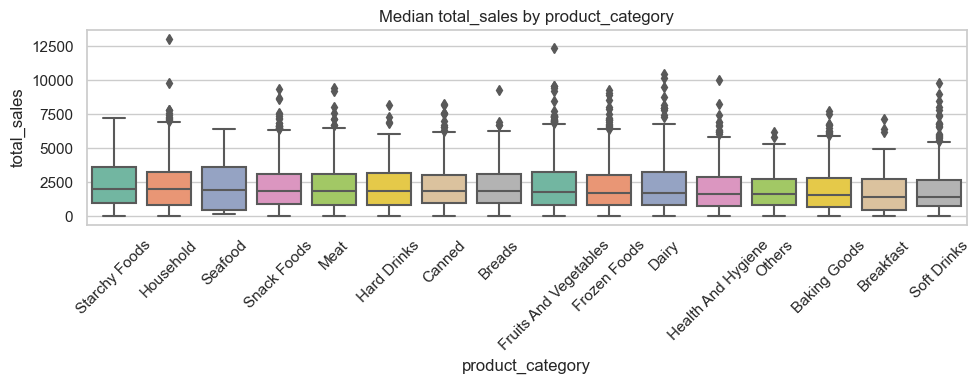

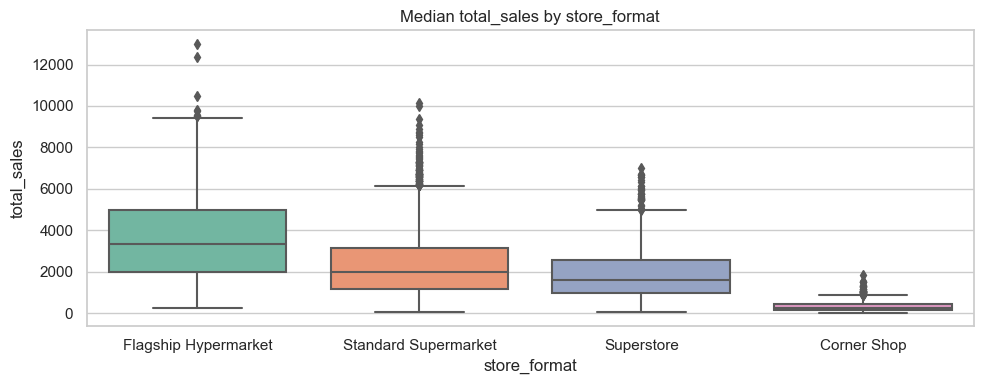

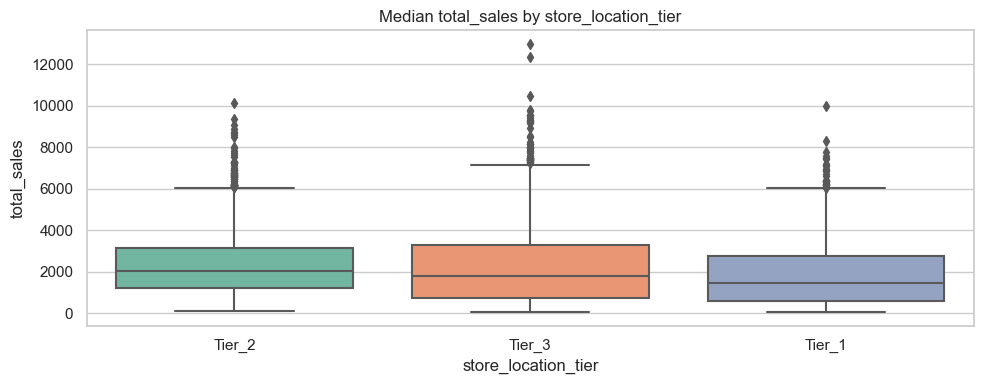

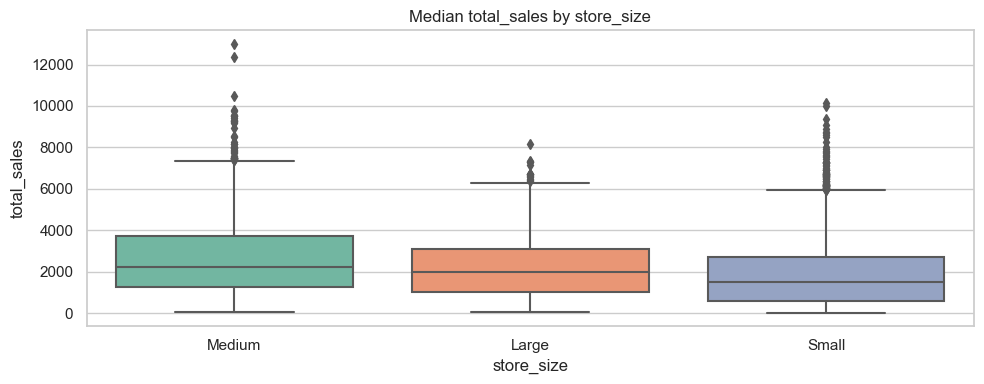

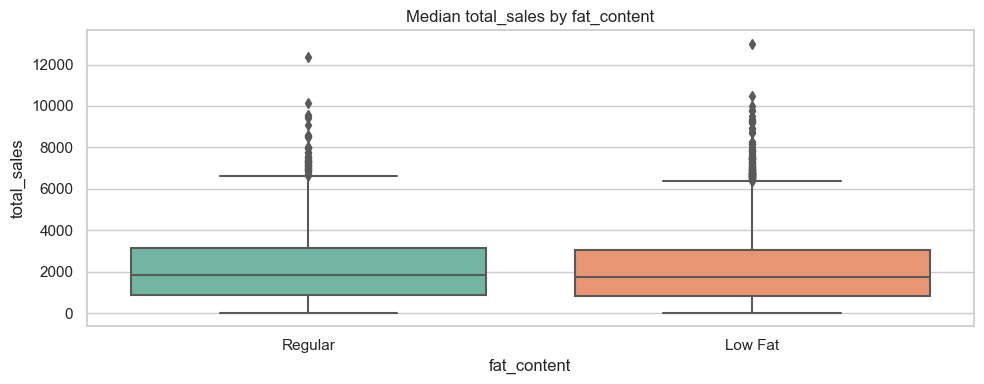

In [5]:
cat_cols = ['product_category', 'store_format', 'store_location_tier', 'store_size', 'fat_content']

for col in cat_cols:
    plt.figure(figsize=(10, 4))
    order = train.groupby(col)['total_sales'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='total_sales', order=order, palette='Set2')
    plt.xticks(rotation=45 if train[col].nunique() > 5 else 0)
    plt.title(f'Median total_sales by {col}')
    plt.tight_layout()
    plt.show()

* Numerical Feature Correlations

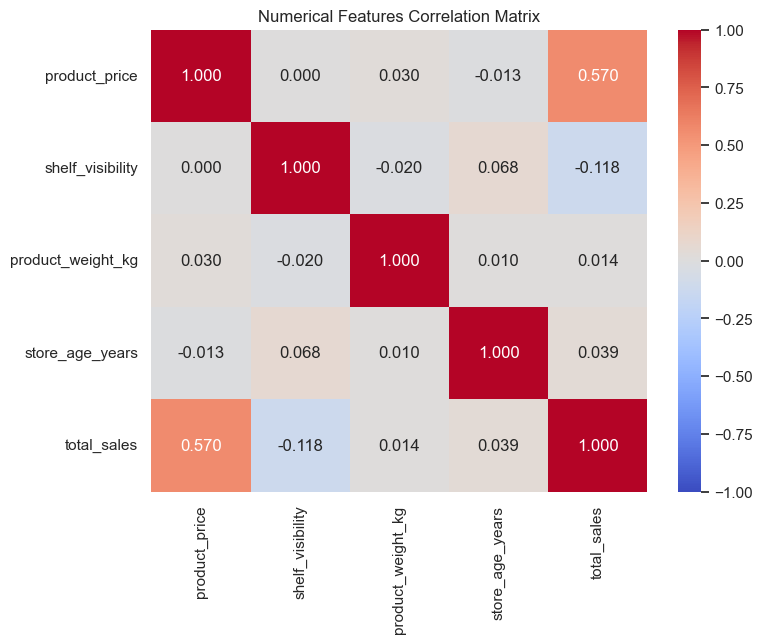

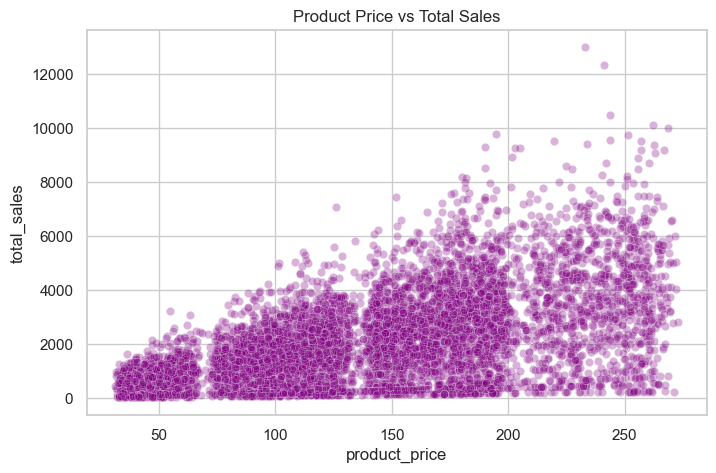

In [6]:
num_cols = ['product_price', 'shelf_visibility', 'product_weight_kg', 'store_age_years', 'total_sales']
corr = train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numerical Features Correlation Matrix')
plt.show()

# Scatter plot: product_price vs. total_sales
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train, x='product_price', y='total_sales', alpha=0.3, color='purple')
plt.title('Product Price vs Total Sales')
plt.show()

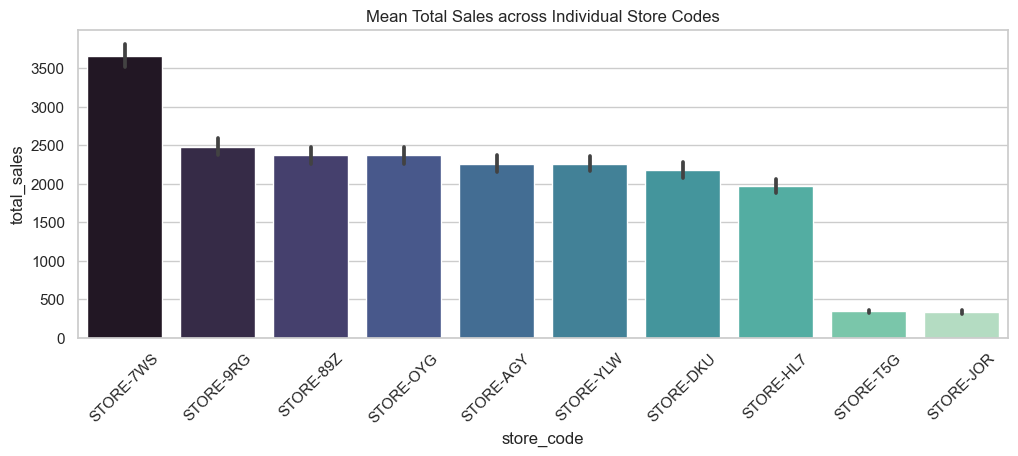

In [8]:
# Store Code Level Performance
plt.figure(figsize=(12, 4))
store_order = train.groupby('store_code')['total_sales'].mean().sort_values(ascending=False).index
sns.barplot(data=train, x='store_code', y='total_sales', order=store_order, palette='mako')
plt.title('Mean Total Sales across Individual Store Codes')
plt.xticks(rotation=45)
plt.show()


* Train vs Test Distribution Drift Check

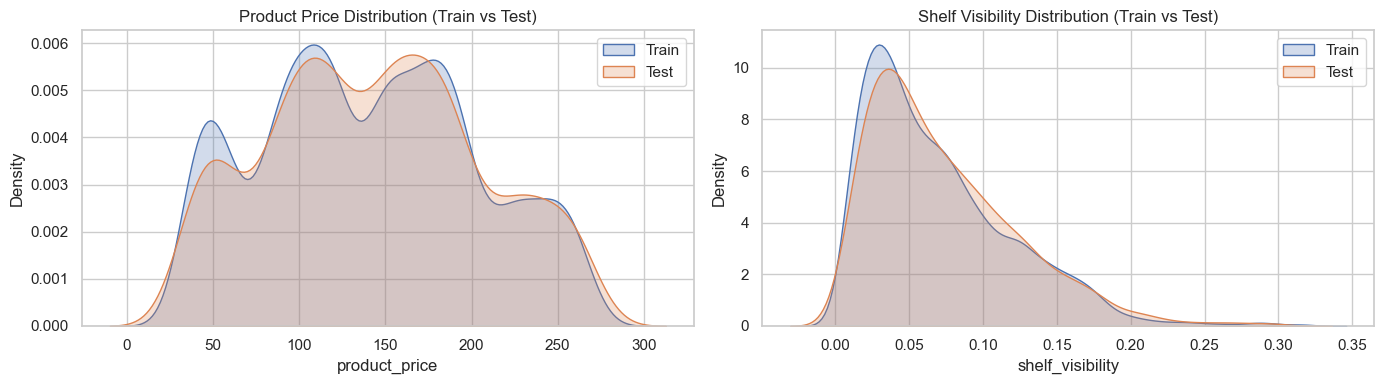

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(train['product_price'], label='Train', ax=axes[0], shade=True)
sns.kdeplot(test['product_price'], label='Test', ax=axes[0], shade=True)
axes[0].set_title('Product Price Distribution (Train vs Test)')
axes[0].legend()

sns.kdeplot(train['shelf_visibility'], label='Train', ax=axes[1], shade=True)
sns.kdeplot(test['shelf_visibility'], label='Test', ax=axes[1], shade=True)
axes[1].set_title('Shelf Visibility Distribution (Train vs Test)')
axes[1].legend()

plt.tight_layout()
plt.show()